In [3]:
import pandas as pd

# 🔹 Load dataset
df = pd.read_csv("Amazon Sale Report (1).csv")

# 🔹 Backup original
original_df = df.copy()

# ---------------- CLEANING ---------------- #

# Remove duplicates
df = df.drop_duplicates()

# Remove completely empty rows
df = df.dropna(how='all')

# Fill missing values
df = df.fillna({
    'Category': 'Unknown',
    'Size': 'Unknown',
    'Fulfilment': 'Unknown'
})

# ✅ FIXED DATE CONVERSION (no warning now)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

# Convert numeric columns
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce')
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Remove invalid values
df = df[df['Amount'] > 0]
df = df[df['Qty'] > 0]

# Clean column names
df.columns = df.columns.str.strip()

# Create new columns (important for dashboard)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month Year'] = df['Date'].dt.strftime('%b %Y')
df['Sales_per_Unit'] = df['Amount'] / df['Qty']

# Optional: remove rows where Date failed to parse
df = df.dropna(subset=['Date'])

# ---------------- SAVE FILES ---------------- #

# Save original dataset (unchanged)
original_df.to_csv("original_amazon_sales.csv", index=False)

# Save cleaned dataset
df.to_csv("cleaned_amazon_sales.csv", index=False)

print("✅ Data cleaned successfully!")
print("📁 Files created:")
print("1. original_amazon_sales.csv")
print("2. cleaned_amazon_sales.csv")

C:\Users\raagh\AppData\Local\Temp\ipykernel_18188\1778254594.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)


✅ Data cleaned successfully!
📁 Files created:
1. original_amazon_sales.csv
2. cleaned_amazon_sales.csv


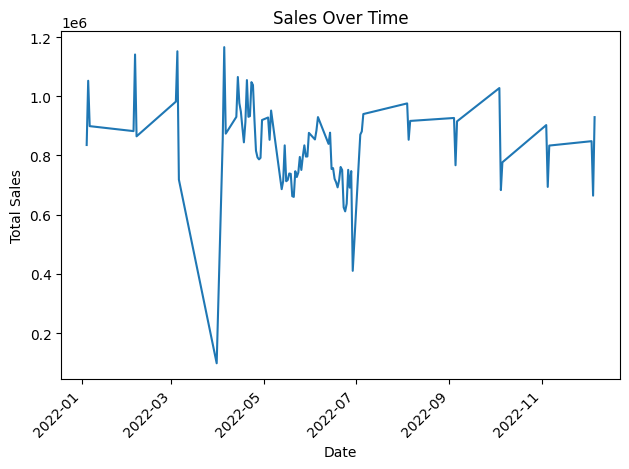

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_amazon_sales.csv")

df['Date'] = pd.to_datetime(df['Date'])
sales_trend = df.groupby('Date')['Amount'].sum()

plt.figure()
sales_trend.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

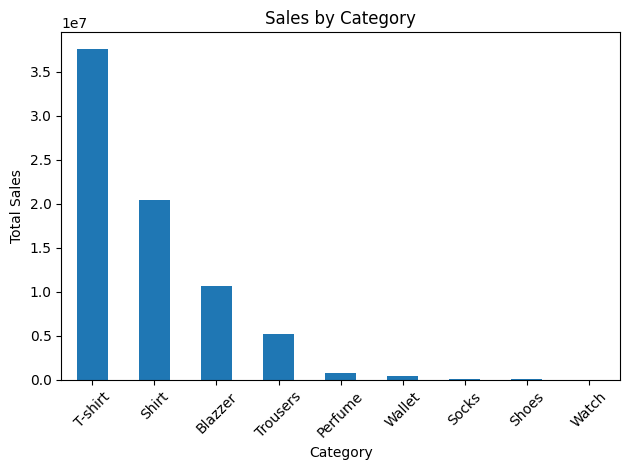

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_amazon_sales.csv")

category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

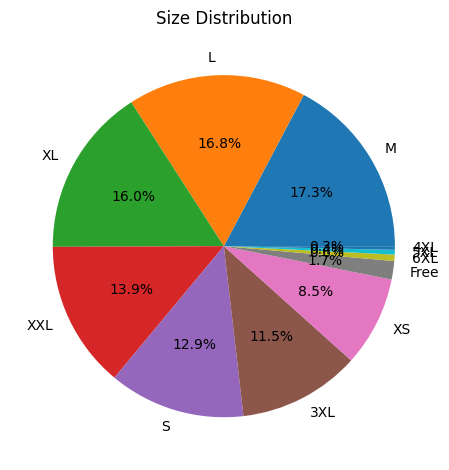

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_amazon_sales.csv")

size_counts = df['Size'].value_counts()

plt.figure()
size_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Size Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

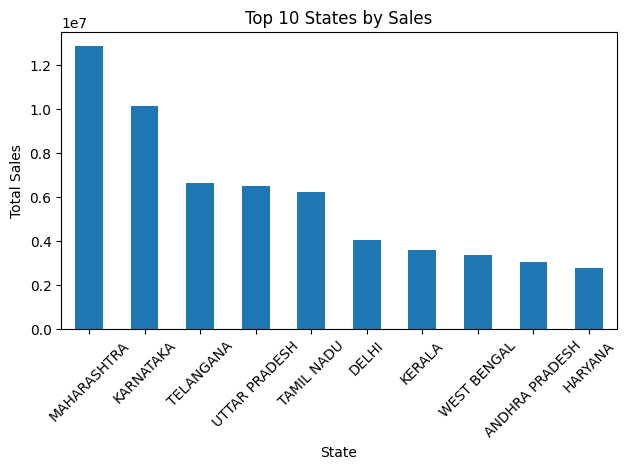

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_amazon_sales.csv")

state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure()
state_sales.plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

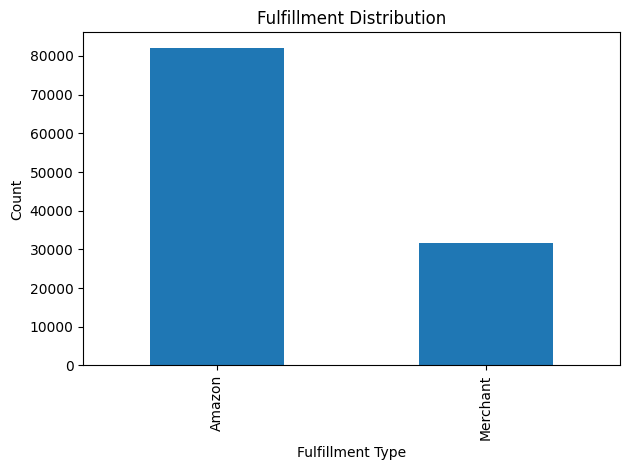

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_amazon_sales.csv")

fulfillment = df['Fulfilment'].value_counts()

plt.figure()
fulfillment.plot(kind='bar')
plt.title("Fulfillment Distribution")
plt.xlabel("Fulfillment Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

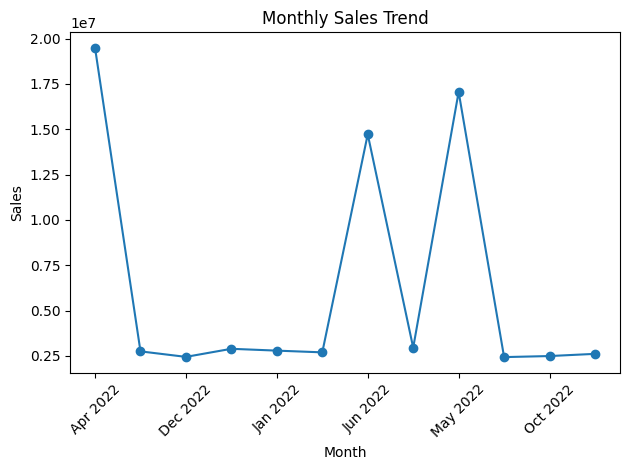

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_amazon_sales.csv")

# ✅ Ensure Date is properly converted (safe)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ✅ Remove invalid dates
df = df.dropna(subset=['Date'])

# ✅ Create Month-Year in string format (better for plotting)
df['Month Year'] = df['Date'].dt.strftime('%b %Y')

# ✅ Group data
monthly_sales = df.groupby('Month Year')['Amount'].sum()

# ✅ Sort correctly (VERY IMPORTANT)
monthly_sales = monthly_sales.sort_index()

# ✅ Plot
plt.figure()
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()